# **Ring Resonator**
*Notebook for Implementation and Testing of Ring Resonator Simulation*


In [40]:
# general imports
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# ml imports
import torch
import torch.nn.functional as F


# import module
from nlse import *

In [41]:
"""-----Primary Parameters-----"""
# define simulation parameters used in inverse design
Lz = 1e-3               # Propagation distance in km (1cm = 1e-5)
Nz = 10              # Number of steps in z
dz = Lz / Nz            # Step size in z
Lt = 3                  # Temporal window size
Nt = 2048               # Number of temporal points
dt = Lt / Nt
N_modes = 100

# define medium parameters
beta2_j = -10           # anomalous GVD region
beta2_k = -10           # anomalous GVD region
gamma_j = 1
gamma_k = 1

# define pulse parameters
tau = 0.1               # temporal width of the pulse = 100 fs - also, characteristic time of Hermite-Gauss basis used in simulation

# define ring resonator parameters
R = 0.7
T = 1 - R
r_coeff = np.sqrt(R)
t_coeff = np.sqrt(T)

# define HG basis
t = torch.linspace(-Lt/2, Lt/2, Nt)
hg_basis = get_hg_basis(N_modes, t, tau)

Precomputed 100 HG basis functions on grid of 2048 points on device cpu


In [42]:
"""-----Secondary Parameters-----"""
# input pulse parameters
amplitude = 0.32 # roughly that of weak soliton used in training

# loops in resonator
N_total = 50

# --- Stack parametrization mode ---
# "vanilla"  : both weak and strong every round (full overlap)
# "overlap"  : weak pulses for rounds [0, weak_end), strong for [strong_start, N_total)
# "periodic" : strong every round, weak injected every M-th round
stack_mode = "vanilla"

# overlap parameters
strong_start = 10
weak_end = 25

# periodic parameters
M = 2  # inject weak pulse every M-th round

In [43]:
def gaussian(t, tau, amplitude):
    """Generate a Gaussian pulse using PyTorch."""
    return amplitude * torch.exp(-(t ** 2) / (2 * tau ** 2))

weak_input = gaussian(t, tau, amplitude)
dummy_input = torch.zeros_like(t)

### **Simulation Code**
For now we simulate using XPM but with a dummy strong pulse

In [44]:
# propagation function for pulse in resonator
def propagate_L(A0_j, A0_k, dz, Nz, beta2_j, beta2_k, gamma_j, gamma_k, Lt, strangsplitting = True): # A_j = weak, A_k = strong
    """Propagate Weak (j) and Strong (k) Pulse Distance L (in Ring Resonator)"""
    A_j = A0_j.clone()
    A_k = A0_k.clone()
    Nt = len(A_j)
    dt = Lt / Nt
    A_j_evolution = torch.zeros((Nt, Nz+1), dtype=torch.complex64, device=A0_j.device)
    A_k_evolution = torch.zeros((Nt, Nz+1), dtype=torch.complex64, device=A0_k.device)
    A_j_evolution[:, 0] = A0_j  # Set first column of A_j_evolution to be the initial pulse
    A_k_evolution[:, 0] = A0_k  # Set first column of A_k_evolution to be the initial pulse

    for i in range(Nz):
        # we want to preserve symmetry in both of the waves - always use the wave at i-th step to go to i+1-th step ? is this that important?
        _A_j = A_j.clone() 
        _A_k = A_k.clone()
        
        if strangsplitting:
            A_j = nonlinear_operator_xpm(gamma_j, _A_j, _A_k, dz/2)  # Apply XPM nonlinear operator
            A_j = dispersion_operator(A_j, beta2_j, Nt, dt, dz)  # Apply dispersion operator
            A_j = nonlinear_operator_xpm(gamma_j, A_j, _A_k, dz/2)  # Apply XPM nonlinear operator
            
            A_k = nonlinear_operator_xpm(gamma_k, _A_k, _A_j, dz/2)  # Apply XPM nonlinear operator
            A_k = dispersion_operator(A_k, beta2_k, Nt, dt, dz)  # Apply dispersion operator
            A_k = nonlinear_operator_xpm(gamma_k, A_k, _A_j, dz/2)  # Apply XPM nonlinear operator
            
            A_j_evolution[:, i+1] = A_j
            A_k_evolution[:, i+1] = A_k
            
        else:
            # for weak wave j
            A_j = nonlinear_operator_xpm(gamma_j, _A_j, _A_k, dz)  # Apply XPM nonlinear operator
            A_j = dispersion_operator(A_j, beta2_j, Nt, dt, dz)  # Apply dispersion operator
            A_j_evolution[:, i+1] = A_j
            
            # for strong wave k
            A_k = nonlinear_operator_xpm(gamma_k, _A_k, _A_j, dz)  # Apply XPM nonlinear operator
            A_k = dispersion_operator(A_k, beta2_k, Nt, dt, dz)  # Apply dispersion operator
            A_k_evolution[:, i+1] = A_k
            
    return A_j_evolution, A_k_evolution

# beam splitter function 
# *only for weak pulse for now
def beam_splitter(a, d, r, t): 
    """Beam Splitter"""
    '''a - pulse from waveguide, d - pulse from resonator'''
    b = t*a + r*d # into resonator
    c = r*a + t*d # out of resonator
    return b, c

In [45]:
"""-----Simulation Setup-----"""
resonator_energy = []
pulse_snaps = [] # stores pulse amplitudes

In [46]:
"""-----Simulation-----"""
# input into resonator is what gets transmitted
A_j = weak_input * t_coeff
A_k = dummy_input * t_coeff

resonator_energy.append(get_energy(A_j, dt))
pulse_snaps.append(A_j.numpy())

# simulate resonator
for i in tqdm(range(N_total), desc="Resonator Loop"):
    # propagate L in resonator
    A_j_ev, _ = propagate_L(A_j, A_k, dz, Nz, beta2_j, beta2_k, gamma_j, gamma_k, Lt)
    A_j = A_j_ev[:, -1]
    
    # beam splitter
    A_j, _ = beam_splitter(weak_input, A_j, r_coeff, t_coeff)
    
    # save energy and pulse
    resonator_energy.append(get_energy(A_j, dt))
    pulse_snaps.append(A_j.numpy())

Resonator Loop:   0%|          | 0/50 [00:00<?, ?it/s]

Resonator Loop: 100%|██████████| 50/50 [00:01<00:00, 49.08it/s]


### **Analytical Solution**

In [47]:
# variables for analytical solution
analytical_energy = []
analytical_pulse_snaps = []


for n in range(1, N_total+2):
    # get analytical pulse
    new_pulse = t_coeff * weak_input * (1-r_coeff**n)/(1-r_coeff)
    analytical_pulse_snaps.append(new_pulse.numpy())
    analytical_energy.append(get_energy(new_pulse, dt))
    
# also define baseline energy
baseline_energy = get_energy(weak_input, dt)

## **Simulation**

Pulse Setup

In [48]:
"""-----Pulse Setup-----"""
def strong_soliton(t, beta2_k, gamma_k, tau):
    """Create the strong pulse (A_k) based on the soliton parameters."""
    a_2_squared = -beta2_k / (gamma_k * tau**2)
    a_2 = np.sqrt(a_2_squared)
    return a_2 * torch.cosh(t / tau)**(-1)

def build_stacks(mode, N_total, Nt, weak_input, t, beta2_k, gamma_k, tau,
                 strong_start=0, weak_end=None, M=1):
    """Build A_j_stack and A_k_stack for the chosen parametrization.

    Modes
    -----
    "vanilla"  : weak and strong every round (full overlap).
    "overlap"  : weak in rounds [0, weak_end), strong in [strong_start, N_total).
    "periodic" : strong every round, weak injected every M-th round (0, M, 2M, …).
    """
    if weak_end is None:
        weak_end = N_total

    A_j = torch.zeros((N_total, Nt), dtype=weak_input.dtype, device=weak_input.device)
    A_k = torch.zeros((N_total, Nt), dtype=weak_input.dtype, device=weak_input.device)
    strong_pulse = strong_soliton(t, beta2_k, gamma_k, tau)

    if mode == "vanilla":
        for i in range(N_total):
            A_j[i] = weak_input
            A_k[i] = strong_pulse

    elif mode == "overlap":
        for i in range(0, weak_end):
            A_j[i] = weak_input
        for i in range(strong_start, N_total):
            A_k[i] = strong_pulse

    elif mode == "periodic":
        for i in range(N_total):
            A_k[i] = strong_pulse
            if i % M == 0:
                A_j[i] = weak_input

    else:
        raise ValueError(f"Unknown stack_mode '{mode}'. Choose 'vanilla', 'overlap', or 'periodic'.")

    return A_j, A_k

A_j_stack, A_k_stack = build_stacks(
    stack_mode, N_total, Nt, weak_input, t, beta2_k, gamma_k, tau,
    strong_start=strong_start, weak_end=weak_end, M=M,
)

In [49]:
"""-----Simulation Setup-----"""
resonator_energy = []
pulse_snaps = []

In [50]:
"""-----Simulation-----"""
# input into resonator is what gets transmitted
A_j = A_j_stack[0] * t_coeff

resonator_energy.append(get_energy(A_j, dt))
pulse_snaps.append(A_j.numpy())

# simulate resonator
for i in tqdm(range(N_total), desc="Resonator Loop"):
    # propagate L in resonator
    A_j_ev, _ = propagate_L(A_j, A_k_stack[i]*t_coeff, dz, Nz, beta2_j, beta2_k, gamma_j, gamma_k, Lt)
    A_j = A_j_ev[:, -1]
    
    # beam splitter
    A_j, _ = beam_splitter(A_j_stack[i], A_j, r_coeff, t_coeff)
    
    # save energy
    resonator_energy.append(get_energy(A_j, dt))
    pulse_snaps.append(A_j.numpy())

Resonator Loop: 100%|██████████| 50/50 [00:00<00:00, 50.61it/s]


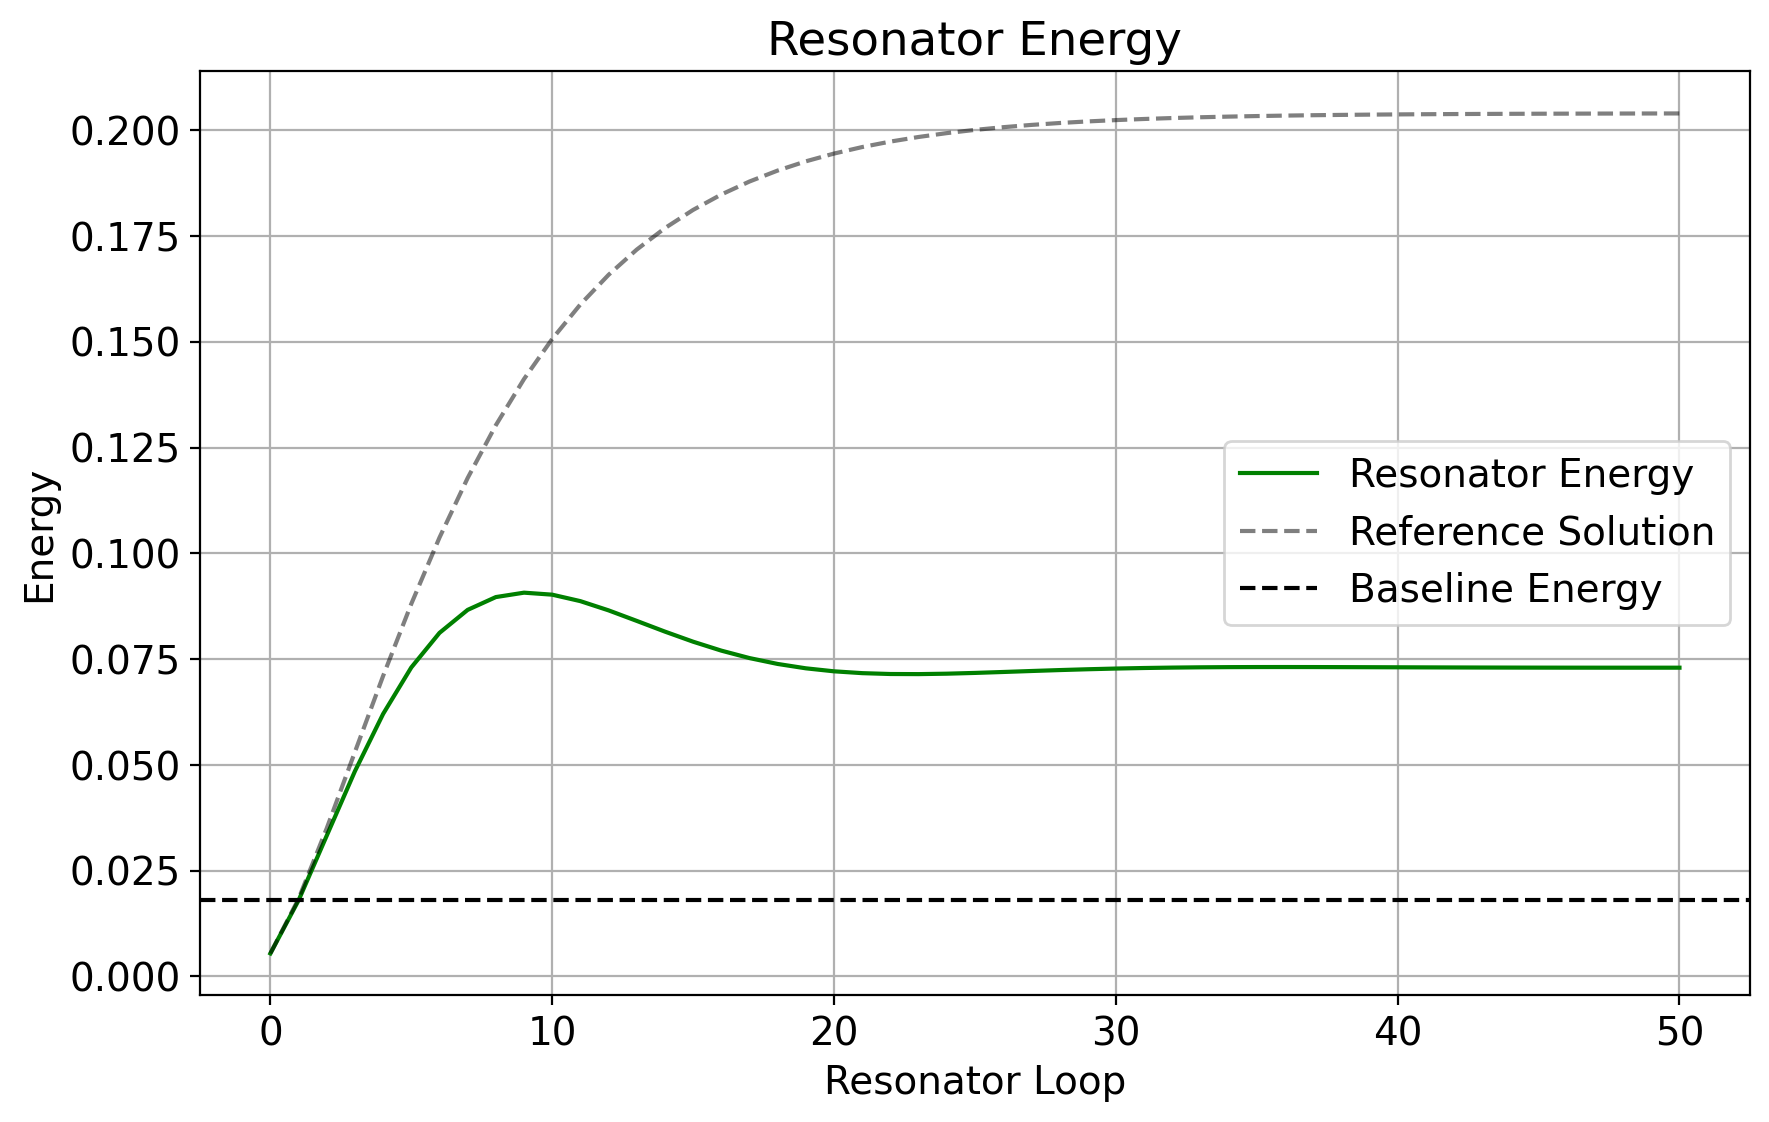

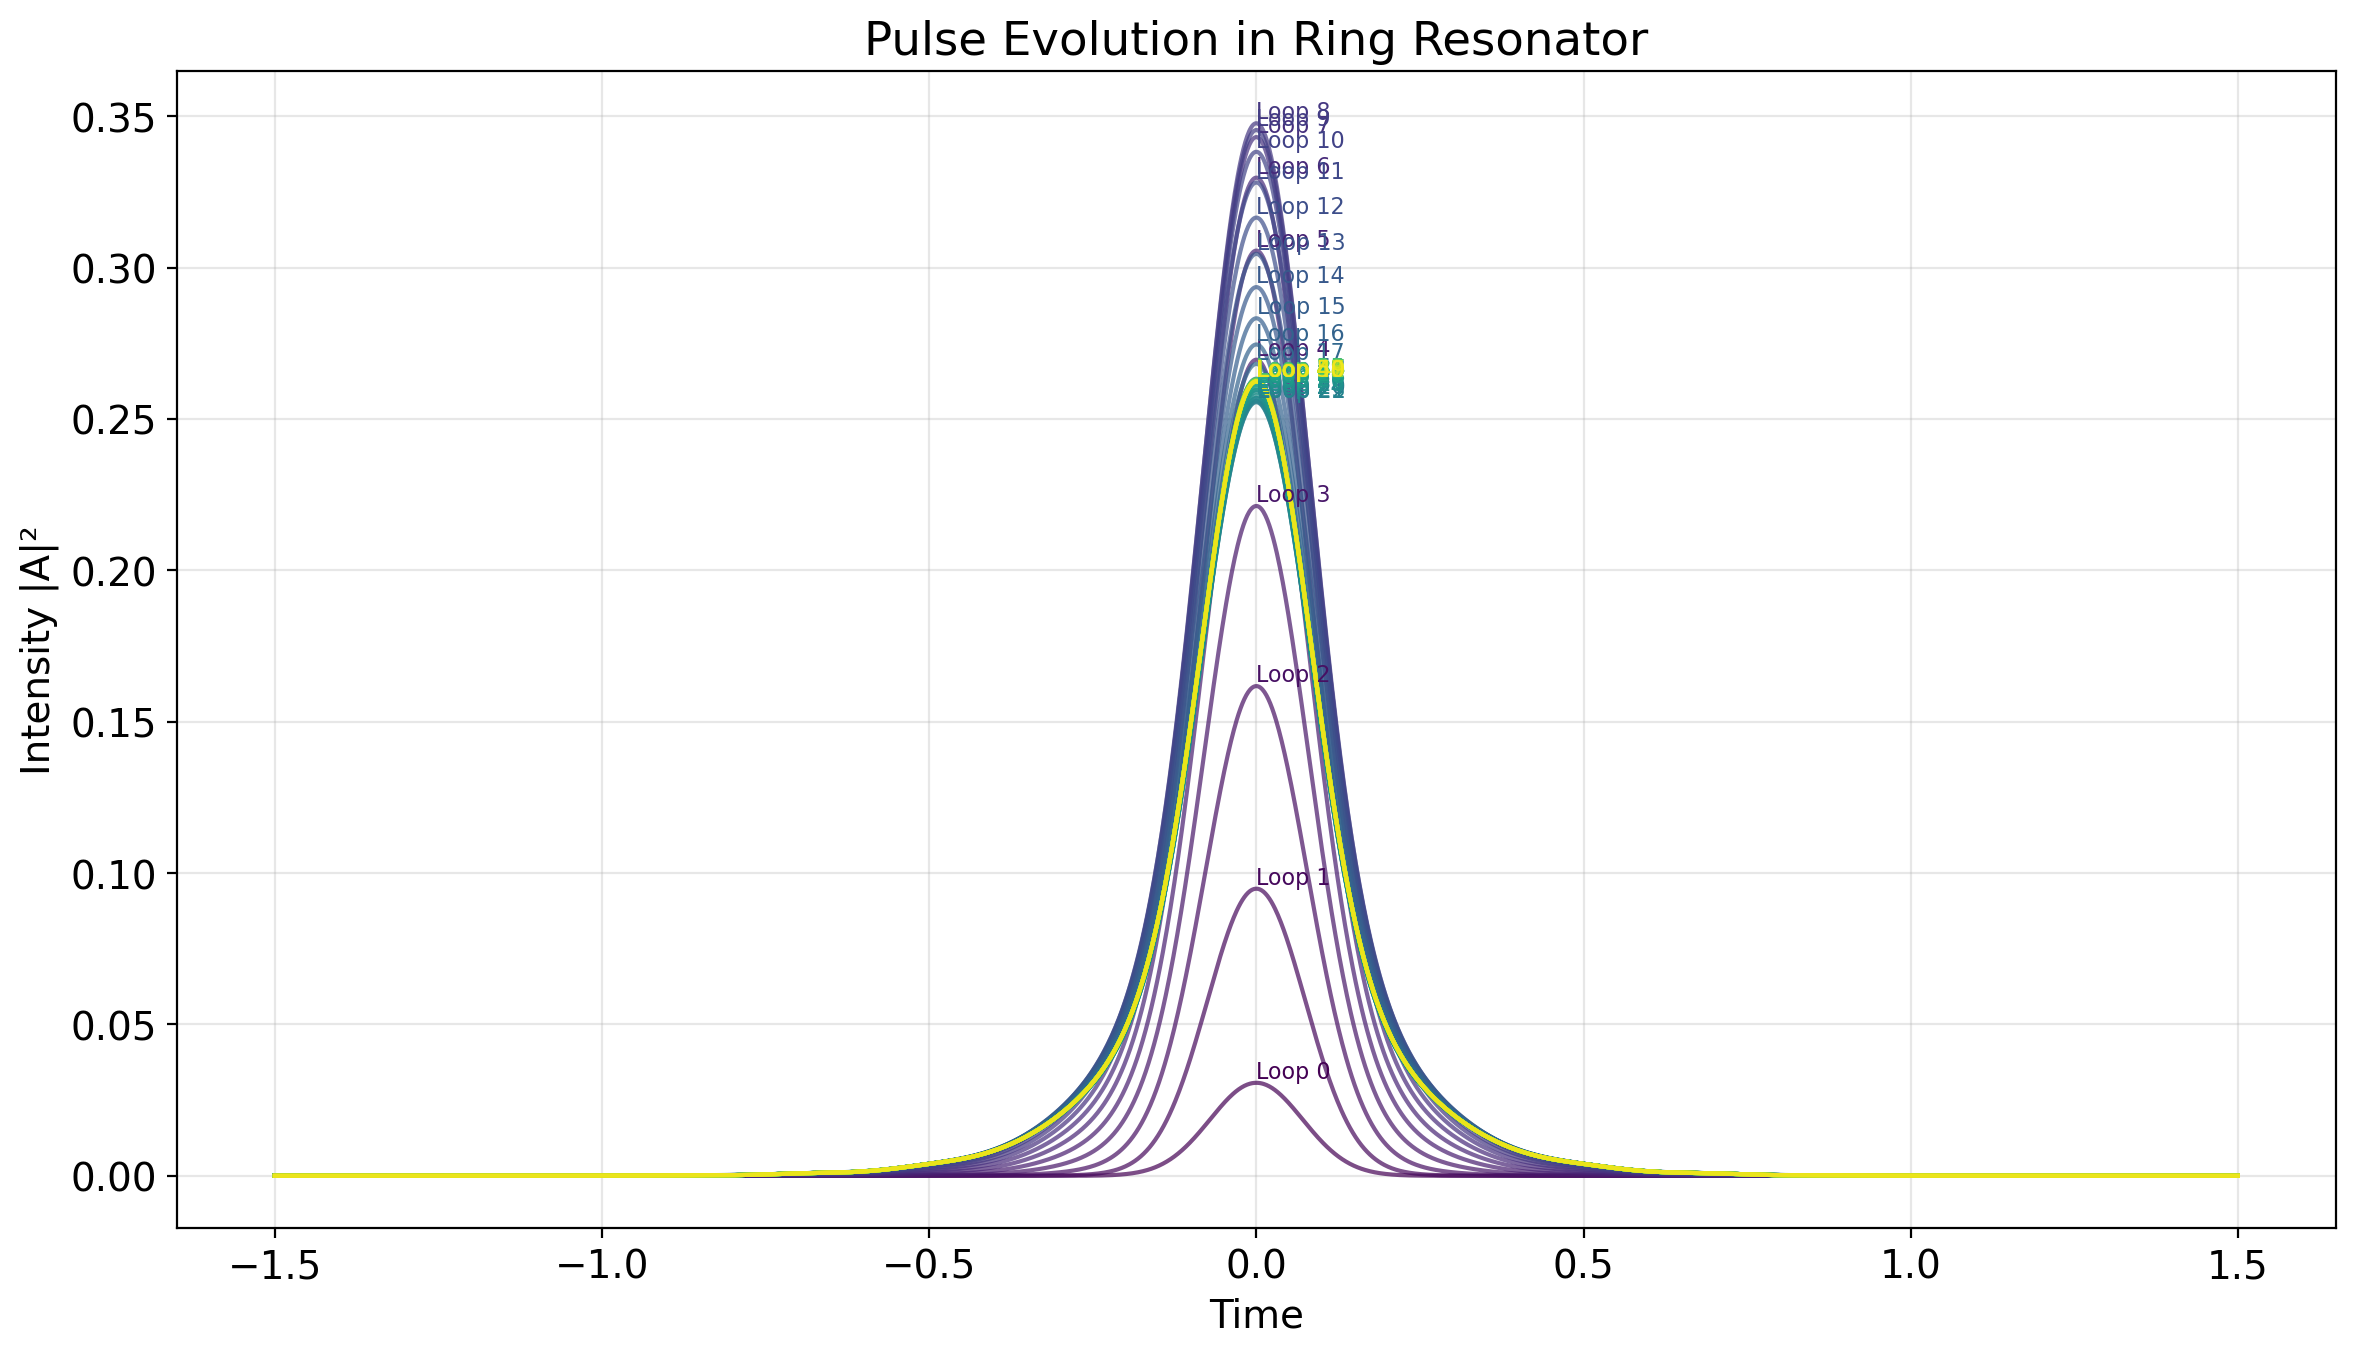

In [51]:
"""-----Plotting-----"""
fig = plt.figure(figsize=(10, 6), dpi=200)
plt.plot(resonator_energy, label="Resonator Energy", color="g")
plt.plot(analytical_energy, label="Reference Solution", linestyle="--", color="k", alpha=0.5)
plt.axhline(baseline_energy, color="k", linestyle="--", label="Baseline Energy")
plt.legend()
plt.xlabel("Resonator Loop")
plt.ylabel("Energy")
plt.title("Resonator Energy")
plt.grid(True)
plt.show()


fig = plt.figure(figsize=(12, 7), dpi=200)
# Create colormap for iterated colors
cmap = plt.cm.viridis  # or 'plasma', 'coolwarm', 'jet', etc.
colors = [cmap(i / len(pulse_snaps)) for i in range(len(pulse_snaps))]
# Plot each pulse snapshot
for i, pulse in enumerate(pulse_snaps):
    intensity = np.abs(pulse)**2
    line, = plt.plot(t.cpu().numpy(), intensity, color=colors[i], alpha=0.7, linewidth=1.5)
    
    # Add text label at the peak of each pulse
    max_idx = np.argmax(intensity)
    max_val = intensity[max_idx]
    max_t = t.cpu().numpy()[max_idx]
    
    # Offset text slightly to avoid overlap
    plt.text(max_t, max_val, f'Loop {i}', 
             fontsize=8, 
             ha='left', 
             va='bottom',
             color=colors[i])

plt.xlabel("Time")
plt.ylabel("Intensity |A|²")
plt.title("Pulse Evolution in Ring Resonator")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **Strong Pulse: Varying Propagation Distance $L_z$**
Rerun the strong-pulse ring resonator simulation for 5 values of $L_z$ spaced logarithmically between $10^{-5}$ and $10^{-3}$, overlaying all energy curves on a single plot.

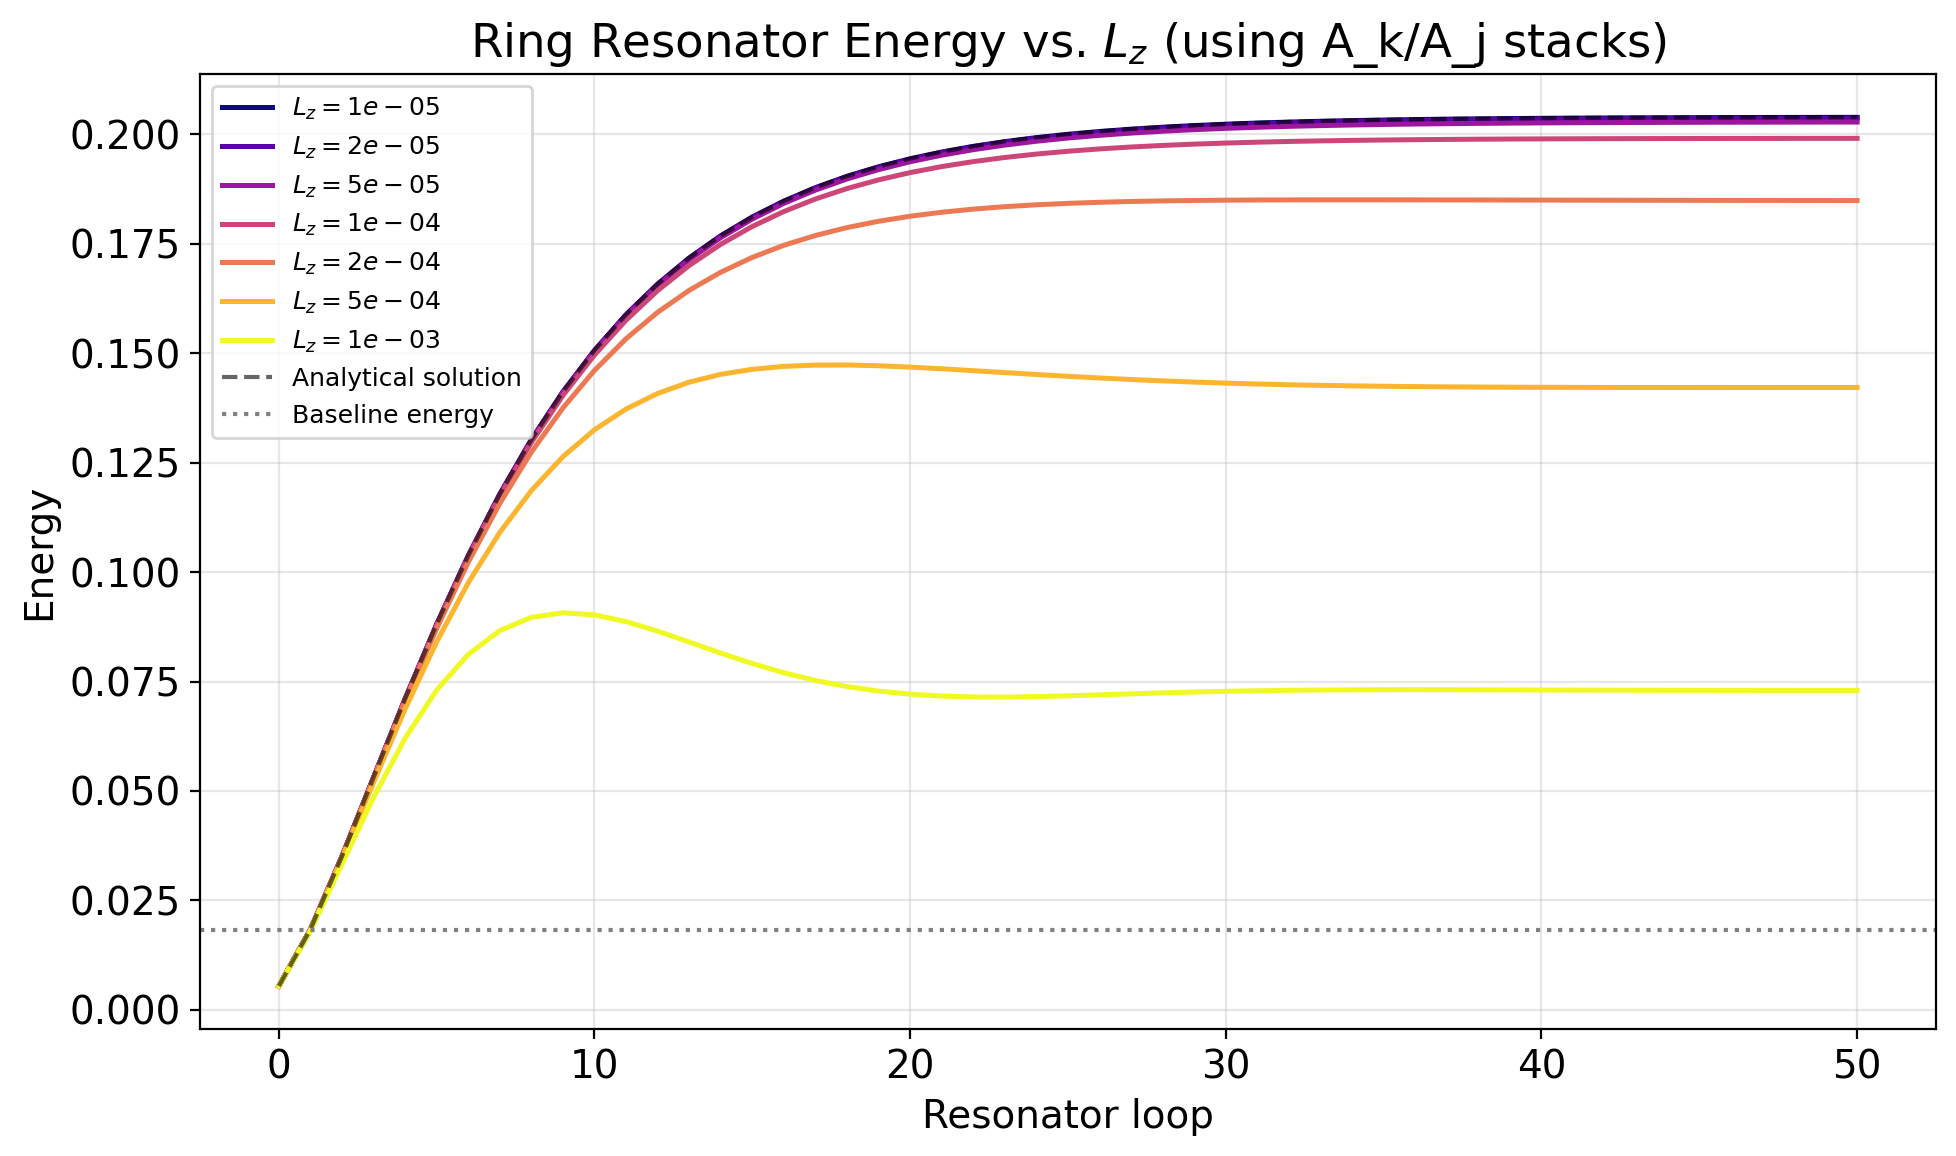

In [52]:
"""-----Lz Sweep using A_k_stack / A_j_stack-----"""
Lz_values = np.logspace(-5, -3, 7)  # 7 values from 1e-5 to 1e-3

# use a perceptually-uniform colormap for the Lz curves
sweep_cmap = plt.cm.plasma
sweep_colors = [sweep_cmap(i / (len(Lz_values) - 1)) for i in range(len(Lz_values))]

fig, ax = plt.subplots(figsize=(10, 6), dpi=200)

for idx, Lz_val in enumerate(Lz_values):
    Nz_val = 10
    dz_val = Lz_val / Nz_val

    # initialise
    energy_run = []
    A_j_run = A_j_stack[0] * t_coeff
    energy_run.append(get_energy(A_j_run, dt))

    for i in tqdm(range(N_total), desc=f'Lz={Lz_val:.1e}', leave=False):
        A_j_ev, _ = propagate_L(
            A_j_run, A_k_stack[i] * t_coeff,
            dz_val, Nz_val,
            beta2_j, beta2_k, gamma_j, gamma_k, Lt
        )
        A_j_run = A_j_ev[:, -1]
        A_j_run, _ = beam_splitter(A_j_stack[i], A_j_run, r_coeff, t_coeff)
        energy_run.append(get_energy(A_j_run, dt))

    ax.plot(
        energy_run,
        color=sweep_colors[idx],
        linewidth=1.8,
        label=f'$L_z={Lz_val:.0e}$'
    )

# overlay reference curves
ax.plot(analytical_energy, linestyle='--', color='black', alpha=0.6, linewidth=1.5, label='Analytical solution')
ax.axhline(baseline_energy, linestyle=':', color='gray', linewidth=1.5, label='Baseline energy')

ax.set_xlabel('Resonator loop')
ax.set_ylabel('Energy')
ax.set_title('Ring Resonator Energy vs. $L_z$ (using A_k/A_j stacks)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
